## 1. Modules

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import distance_transform_edt

## 2. Mounting drive

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

## 3. Dataset

In [4]:
# DRIVE_EXT = "/content/drive/My Drive/"
FOLDER_EXT = "RVG_Merged_Dataset"
IMAGE_DIR = f"{FOLDER_EXT}/images"
MASK_DIR = f"{FOLDER_EXT}/masks_cleaned"

print("All extensions...")
print(FOLDER_EXT)
print(IMAGE_DIR)
print(MASK_DIR)

All extensions...
RVG_Merged_Dataset
RVG_Merged_Dataset/images
RVG_Merged_Dataset/masks_cleaned


In [5]:
len(os.listdir(IMAGE_DIR)), len(os.listdir(MASK_DIR))

(433, 433)

In [6]:
IMG_SIZE = (512, 512)
BATCH_SIZE = 2
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
def load_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0

    img = tf.pad(
        img,
        paddings=[[5, 5], [10, 10], [0, 0]],
        mode="CONSTANT",
        constant_values=0.0
    )

    return img

def load_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.cast(mask, tf.int32)
    mask = tf.pad(
        mask,
        paddings=[[5, 5], [10, 10], [0, 0]],
        mode="CONSTANT",
        constant_values=0
    )
    return mask

In [8]:
def make_binary_mask(mask, class_id):
    return tf.cast(mask == class_id, tf.float32)

In [9]:
def load_pair(img_path, mask_path, class_id):
    img  = load_image(img_path)
    mask = load_mask(mask_path)
    mask = make_binary_mask(mask, class_id)

    return img, mask

In [10]:
def get_matched_pairs():
    img_files = os.listdir(IMAGE_DIR)
    mask_files = os.listdir(MASK_DIR)

    img_map = {f.replace(".png", ""): os.path.join(IMAGE_DIR, f)
               for f in img_files}

    mask_map = {f.replace("_combined_mask.png", ""): os.path.join(MASK_DIR, f)
                for f in mask_files}

    common_keys = sorted(img_map.keys() & mask_map.keys())

    img_paths  = [img_map[k] for k in common_keys]
    mask_paths = [mask_map[k] for k in common_keys]

    return img_paths, mask_paths


In [11]:
def keep_only_correct_shape(img, mask):
    img_shape  = tf.shape(img)
    mask_shape = tf.shape(mask)

    img_ok = tf.logical_and(
        tf.logical_and(img_shape[0] == 800, img_shape[1] == 1120),
        img_shape[2] == 1
    )

    mask_ok = tf.logical_and(
        tf.logical_and(mask_shape[0] == 800, mask_shape[1] == 1120),
        mask_shape[2] == 1
    )

    return tf.logical_and(img_ok, mask_ok)


In [12]:
def create_binary_dataset(class_id):
    img_paths, mask_paths = get_matched_pairs()

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    ds = ds.map(
        lambda x, y: load_pair(x, y, class_id),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds

In [13]:
enamel_ds  = create_binary_dataset(class_id=1)
dentine_ds = create_binary_dataset(class_id=2)
pulp_ds    = create_binary_dataset(class_id=3)

enamel_ds = enamel_ds.filter(keep_only_correct_shape)
dentine_ds = dentine_ds.filter(keep_only_correct_shape)
pulp_ds = pulp_ds.filter(keep_only_correct_shape)

I0000 00:00:1766754003.030039  612796 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 72887 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:83:00.0, compute capability: 8.0


In [14]:
enamel_ds = (
    enamel_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
dentine_ds = (
    dentine_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
pulp_ds = (
    pulp_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [15]:
N = sum(1 for _ in enamel_ds)

2025-12-26 18:30:15.660834: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
n_test  = N - n_train - n_val
print("train: ", n_train)
print("val: ", n_val)
print("test: ", n_test)

train:  105
val:  13
test:  14


In [17]:
def split_ds(ds, nt, nv, ntt):
  return ds.take(nt), ds.take(nv), ds.take(ntt)

In [18]:
enamel_train, enamel_val, enamel_test = split_ds(enamel_ds, n_train, n_val, n_test)
dentine_train, dentine_val, dentine_test = split_ds(dentine_ds, n_train, n_val, n_test)
pulp_train, pulp_val, pulp_test = split_ds(pulp_ds, n_train, n_val, n_test)

## 4. Model arch

In [19]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

In [20]:
def build_unet(input_shape=(None, None, 1)):
    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs,   32)
    s2, p2 = encoder_block(p1,  64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b = conv_block(p4, 512)

    d1 = decoder_block(b,  s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2,  64)
    d4 = decoder_block(d3, s1,  32)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(d4)

    return Model(inputs, outputs)

## 5. Crazy loss functions

In [21]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (denom + smooth)
    return 1. - dice

def scce_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_true = tf.squeeze(y_true, axis=-1)

    y_pred = tf.concat([1 - y_pred, y_pred], axis=-1)

    return tf.keras.losses.sparse_categorical_crossentropy(
        y_true, y_pred
    )

def focal_tversky_loss(y_true, y_pred,
                       alpha=0.4,
                       beta=0.6,
                       gamma=0.75,
                       smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    TP = tf.reduce_sum(y_true * y_pred)
    FP = tf.reduce_sum((1 - y_true) * y_pred)
    FN = tf.reduce_sum(y_true * (1 - y_pred))

    tversky = (TP + smooth) / (
        TP + alpha * FP + beta * FN + smooth
    )

    return tf.pow((1 - tversky), gamma)

def total_variation_loss(y_pred):
    return tf.reduce_mean(tf.image.total_variation(y_pred))

In [22]:
def combined_loss(y_true, y_pred):

    dice = dice_loss(y_true, y_pred)
    tversky = focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7)
    scce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    # tv = total_variation_loss(y_pred)

    return (
        dice +
        tversky +
        0.5 * scce
    )


## 6. Crazy metrics to track everything

In [23]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    denom = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    return (2. * intersection + smooth) / (denom + smooth)

def recall_sensitivity(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > threshold, tf.float32)

    TP = tf.reduce_sum(y_true * y_pred)
    FN = tf.reduce_sum(y_true * (1 - y_pred))

    return (TP + smooth) / (TP + FN + smooth)

def precision_metric(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > threshold, tf.float32)

    TP = tf.reduce_sum(y_true * y_pred)
    FP = tf.reduce_sum((1 - y_true) * y_pred)

    return (TP + smooth) / (TP + FP + smooth)

def hd95_metric(y_true, y_pred, threshold=0.5):
    """
    Computes the 95th percentile Hausdorff Distance
    """

    def _hd95(y_true_np, y_pred_np):
        y_true_np = y_true_np.astype(np.bool_)
        y_pred_np = (y_pred_np > threshold)

        if not np.any(y_true_np) and not np.any(y_pred_np):
            return np.array(0.0, dtype=np.float32)

        if not np.any(y_true_np) or not np.any(y_pred_np):
            return np.array(1e6, dtype=np.float32)

        dt_true = distance_transform_edt(~y_true_np)
        dt_pred = distance_transform_edt(~y_pred_np)

        surface_pred = dt_true[y_pred_np]
        surface_true = dt_pred[y_true_np]

        hd95 = np.percentile(
            np.concatenate([surface_pred, surface_true]),
            95
        )

        return np.array(hd95, dtype=np.float32)

    return tf.numpy_function(
        _hd95,
        [tf.squeeze(y_true), tf.squeeze(y_pred)],
        tf.float32
    )

## 7. Callbacks (Not crazy)

In [24]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

## 8. Model building for enamel

In [26]:
enamel_model = build_unet()

enamel_model.compile(
    optimizer="adam",
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        recall_sensitivity,
        precision_metric
        #hd95_metric  # Super slow
    ]
)

enamel_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, None,      │        320 │ input_layer_1[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_19[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, None,      │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, None,      │     18,496 │ max_pooling2d_4[… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_21[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, None,      │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, None,      │     73,856 │ max_pooling2d_5[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_23[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, None,      │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, None,      │    295,168 │ max_pooling2d_6[… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, None,      │    590,080 │ conv2d_25[0][0]   │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, None,      │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, None,      │  1,180,160 │ max_pooling2d_7[… │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, None,      │  2,359,808 │ conv2d_27[0][0]   │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, None,      │    524,544 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, None,      │          0 │ conv2d_transpose

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Model training for enamel

In [27]:
enamel_history = enamel_model.fit(
    enamel_train,
    validation_data=enamel_val,
    epochs=50,
    # callbacks=callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1766754064.263035  613263 service.cc:152] XLA service 0x7fb2000037e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766754064.263064  613263 service.cc:160]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2025-12-26 18:31:04.563346: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766754065.344877  613263 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-12-26 18:31:06.789365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-26 18:31:06.951833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, ple

      2/Unknown 37s 70ms/step - dice_coefficient: 0.1326 - loss: 2.0627 - precision_metric: 0.2502 - recall_sensitivity: 1.0190e-04   

I0000 00:00:1766754097.727736  613263 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    105/Unknown 43s 66ms/step - dice_coefficient: 0.1696 - loss: 1.9184 - precision_metric: 0.8986 - recall_sensitivity: 0.0461

...

2025-12-26 18:37:41.503860: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:37:41.503927: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - dice_coefficient: 0.8420 - loss: 0.4442 - precision_metric: 0.8018 - recall_sensitivity: 0.9074

2025-12-26 18:37:48.481767: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:37:48.481843: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - dice_coefficient: 0.8420 - loss: 0.4443 - precision_metric: 0.8018 - recall_sensitivity: 0.9074 - val_dice_coefficient: 0.8685 - val_loss: 0.3922 - val_precision_metric: 0.8406 - val_recall_sensitivity: 0.9086


2025-12-26 18:37:48.785718: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


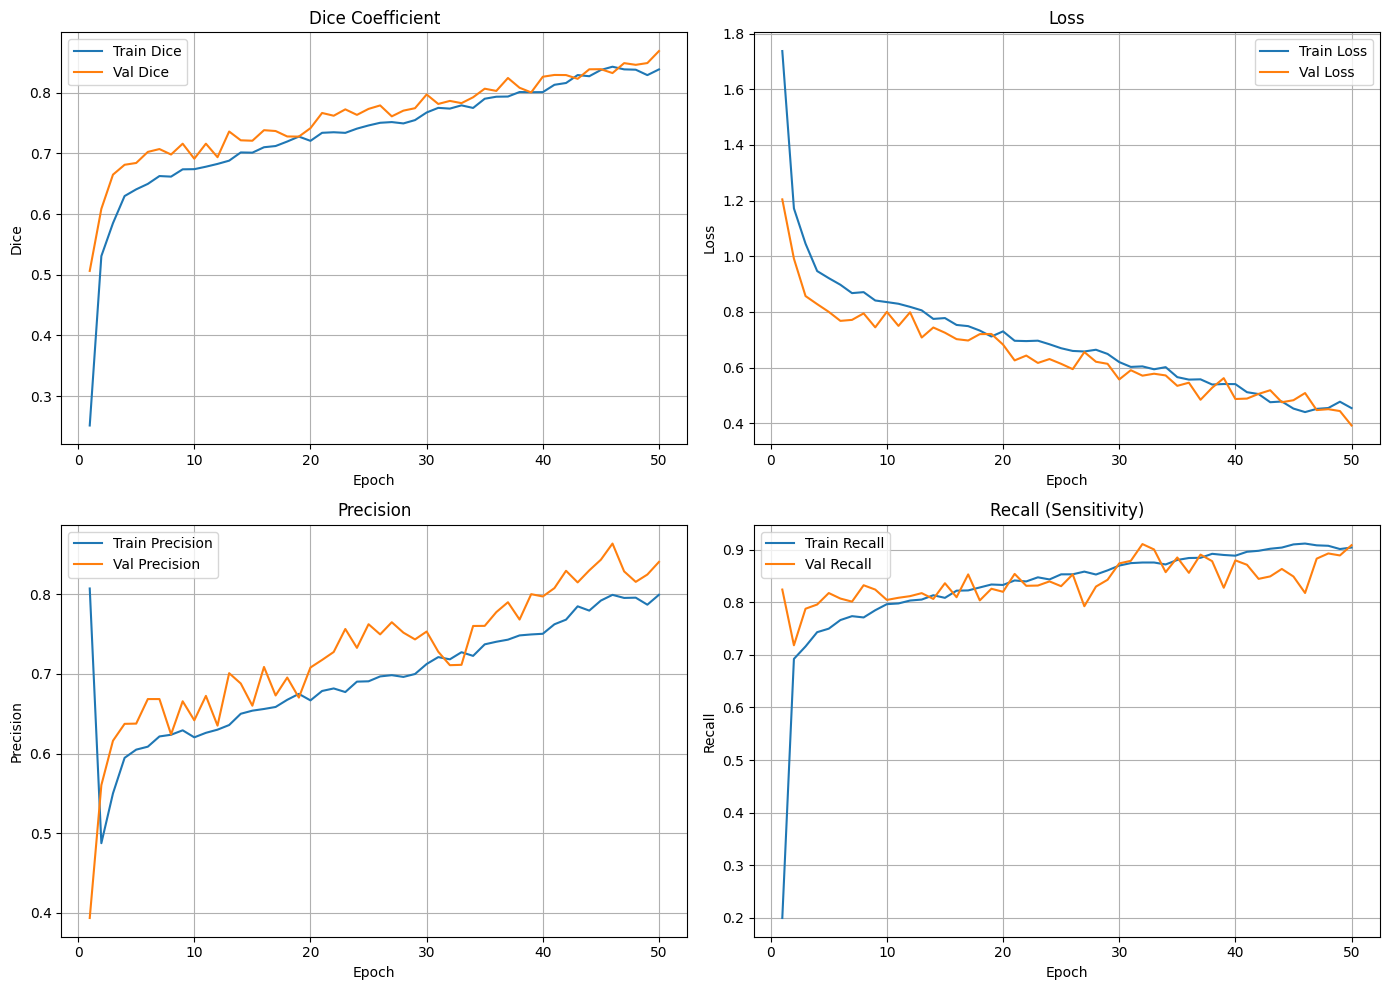

In [28]:
history = enamel_history.history
epochs = range(1, len(history['loss']) + 1)

plt.figure(figsize=(14, 10))

# 1️⃣ Dice
plt.subplot(2, 2, 1)
plt.plot(epochs, history['dice_coefficient'], label='Train Dice')
plt.plot(epochs, history['val_dice_coefficient'], label='Val Dice')
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

# 2️⃣ Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, history['loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 3️⃣ Precision
plt.subplot(2, 2, 3)
plt.plot(epochs, history['precision_metric'], label='Train Precision')
plt.plot(epochs, history['val_precision_metric'], label='Val Precision')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# 4️⃣ Recall
plt.subplot(2, 2, 4)
plt.plot(epochs, history['recall_sensitivity'], label='Train Recall')
plt.plot(epochs, history['val_recall_sensitivity'], label='Val Recall')
plt.title('Recall (Sensitivity)')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.savefig("LossCurves.png", dpi=400)
plt.tight_layout()
plt.show()

In [29]:
test_results = enamel_model.evaluate(enamel_test, verbose=1)

test_metrics = dict(zip(enamel_model.metrics_names, test_results))
test_metrics

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - dice_coefficient: 0.8639 - loss: 0.3904 - precision_metric: 0.8176 - recall_sensitivity: 0.9255


2025-12-26 18:40:42.293961: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:40:42.294019: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


{'loss': 0.41220059990882874, 'compile_metrics': 0.8605661988258362}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step


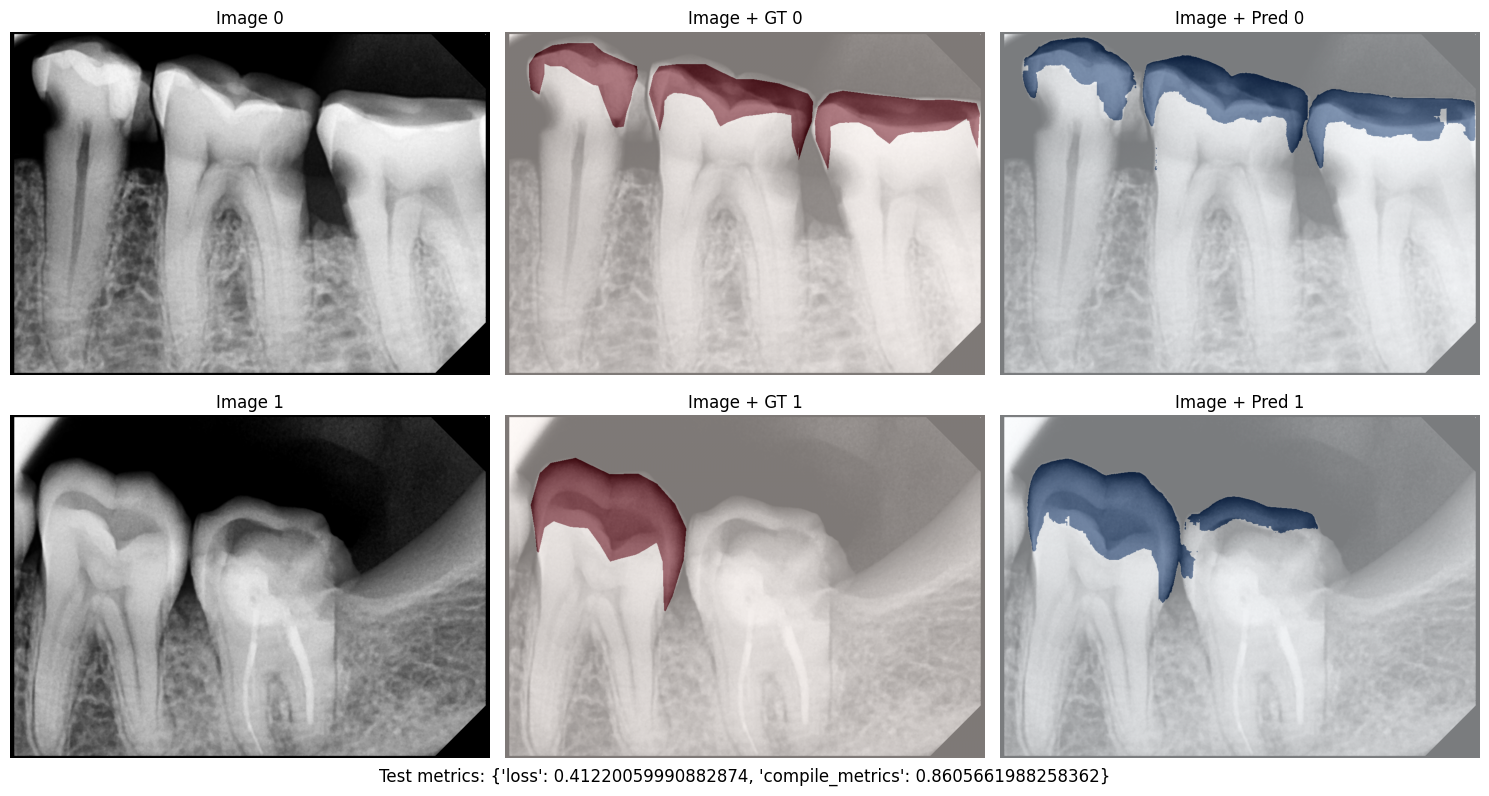

In [30]:
images, gts = next(iter(enamel_test))
enamel_preds = enamel_model.predict(images)

batch_size = images.shape[0]
threshold = 0.2   # try 0.3 later if recall is low
alpha = 0.5       # transparency for overlays

plt.figure(figsize=(15, 4 * batch_size))

for i in range(batch_size):
    img  = images[i, ..., 0]
    gt   = gts[i, ..., 0]
    pred = enamel_preds[i, ..., 0]

    # 1️⃣ Image only
    plt.subplot(batch_size, 3, i * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i}")
    plt.axis("off")

    # 2️⃣ Image + GT overlay
    plt.subplot(batch_size, 3, i * 3 + 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(gt, cmap="Reds", alpha=alpha)
    plt.title(f"Image + GT {i}")
    plt.axis("off")

    # 3️⃣ Image + Prediction overlay
    plt.subplot(batch_size, 3, i * 3 + 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(pred > threshold, cmap="Blues", alpha=alpha)
    plt.title(f"Image + Pred {i}")
    plt.axis("off")

plt.gcf().text(
    0.5, 0.02,
    f"Test metrics: {test_metrics}",
    ha="center",
    va="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("prediction_overlay.png", dpi=400,)
plt.show()


## 10. Model building for Dentine

In [31]:
dentine_model = build_unet()

dentine_model.compile(
    optimizer="adam",
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        recall_sensitivity,
        precision_metric
    ]
)

dentine_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, None,      │        320 │ input_layer_2[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_38[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, None,      │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, None,      │     18,496 │ max_pooling2d_8[… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_40[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, None,      │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, None,      │     73,856 │ max_pooling2d_9[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_42[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, None,      │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, None,      │    295,168 │ max_pooling2d_10… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, None,      │    590,080 │ conv2d_44[0][0]   │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, None,      │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, None,      │  1,180,160 │ max_pooling2d_11… │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, None,      │  2,359,808 │ conv2d_46[0][0]   │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, None,      │    524,544 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, None,      │          0 │ conv2d_transpose

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
dentine_history = dentine_model.fit(
    dentine_train,
    validation_data=dentine_val,
    epochs=50,
    verbose=1
)

Epoch 1/50
    105/Unknown 14s 66ms/step - dice_coefficient: 0.3985 - loss: 1.5854 - precision_metric: 0.3459 - recall_sensitivity: 0.9063

2025-12-26 18:41:21.709754: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion', 8 bytes spill stores, 8 bytes spill loads



105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - dice_coefficient: 0.3989 - loss: 1.5847 - precision_metric: 0.3461 - recall_sensitivity: 0.9060 - val_dice_coefficient: 0.4062 - val_loss: 1.5555 - val_precision_metric: 0.4659 - val_recall_sensitivity: 0.4021
Epoch 2/50
  2/105 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - dice_coefficient: 0.4055 - loss: 1.5514 - precision_metric: 0.5004 - recall_sensitivity: 0.4187  

2025-12-26 18:41:21.968268: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:41:21.968330: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - dice_coefficient: 0.4753 - loss: 1.3915 - precision_metric: 0.4032 - recall_sensitivity: 0.8340 - val_dice_coefficient: 0.5340 - val_loss: 1.2828 - val_precision_metric: 0.5289 - val_recall_sensitivity: 0.6675
Epoch 3/50
  1/105 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - dice_coefficient: 0.5409 - loss: 1.2779 - precision_metric: 0.5506 - recall_sensitivity: 0.6399

...

2025-12-26 18:47:04.604229: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:47:04.604306: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - dice_coefficient: 0.8474 - loss: 0.4981 - precision_metric: 0.8256 - recall_sensitivity: 0.8993 - val_dice_coefficient: 0.8467 - val_loss: 0.5111 - val_precision_metric: 0.8401 - val_recall_sensitivity: 0.8795
Epoch 49/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - dice_coefficient: 0.8553 - loss: 0.4765 - precision_metric: 0.8338 - recall_sensitivity: 0.9052 - val_dice_coefficient: 0.8513 - val_loss: 0.5031 - val_precision_metric: 0.8555 - val_recall_sensitivity: 0.8741
Epoch 50/50
  2/105 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - dice_coefficient: 0.8677 - loss: 0.4458 - precision_metric: 0.8719 - recall_sensitivity: 0.8871  

2025-12-26 18:47:12.222607: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:47:12.222664: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - dice_coefficient: 0.8566 - loss: 0.4719 - precision_metric: 0.8327 - recall_sensitivity: 0.9091 - val_dice_coefficient: 0.8575 - val_loss: 0.4796 - val_precision_metric: 0.8534 - val_recall_sensitivity: 0.8867


2025-12-26 18:47:19.513967: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:47:19.514038: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


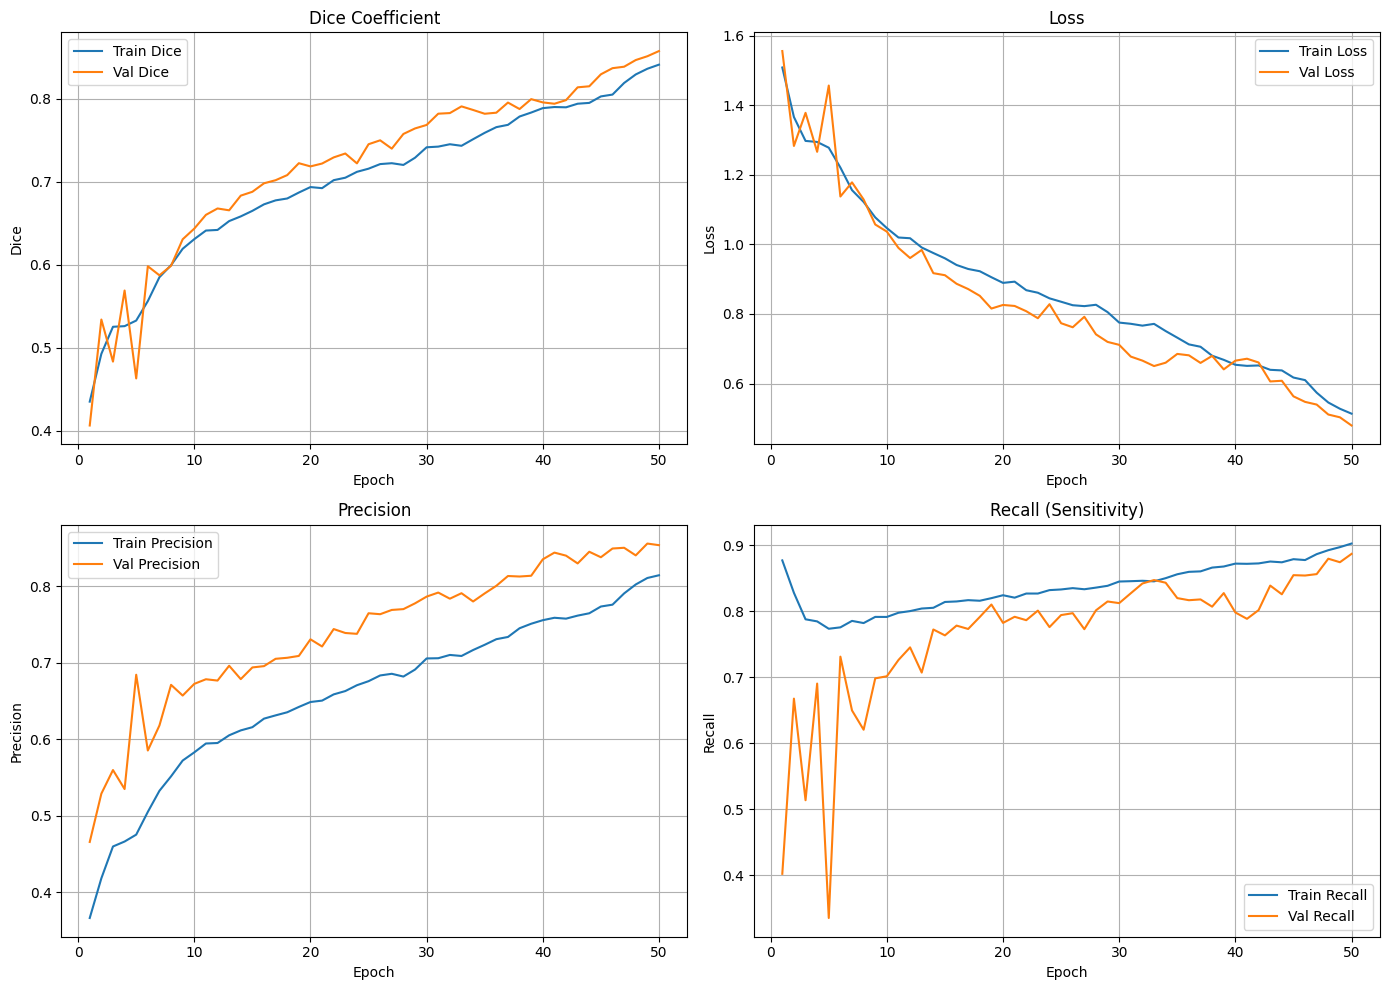

In [33]:
history = dentine_history.history
epochs = range(1, len(history['loss']) + 1)

plt.figure(figsize=(14, 10))

# 1️⃣ Dice
plt.subplot(2, 2, 1)
plt.plot(epochs, history['dice_coefficient'], label='Train Dice')
plt.plot(epochs, history['val_dice_coefficient'], label='Val Dice')
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

# 2️⃣ Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, history['loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 3️⃣ Precision
plt.subplot(2, 2, 3)
plt.plot(epochs, history['precision_metric'], label='Train Precision')
plt.plot(epochs, history['val_precision_metric'], label='Val Precision')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# 4️⃣ Recall
plt.subplot(2, 2, 4)
plt.plot(epochs, history['recall_sensitivity'], label='Train Recall')
plt.plot(epochs, history['val_recall_sensitivity'], label='Val Recall')
plt.title('Recall (Sensitivity)')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.savefig("LossCurves_dentine.png", dpi=400)
plt.tight_layout()
plt.show()

In [34]:
test_results = dentine_model.evaluate(dentine_test, verbose=1)

test_metrics = dict(zip(dentine_model.metrics_names, test_results))
test_metrics

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - dice_coefficient: 0.8669 - loss: 0.4429 - precision_metric: 0.8562 - recall_sensitivity: 0.9022


{'loss': 0.49189066886901855, 'compile_metrics': 0.8543667793273926}

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


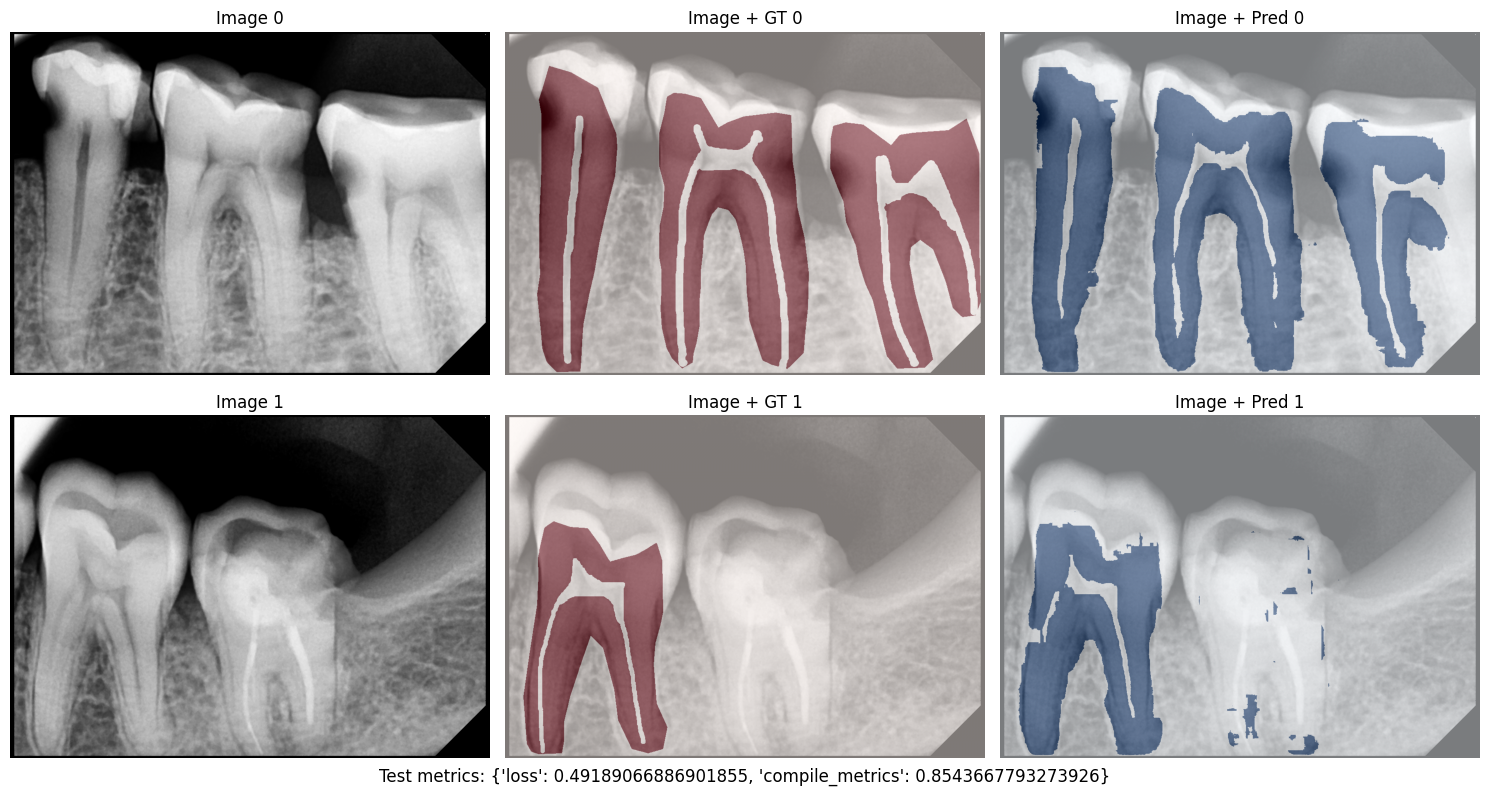

In [35]:
images, gts = next(iter(dentine_test))
dentine_preds = dentine_model.predict(images)

batch_size = images.shape[0]
threshold = 0.2   # try 0.3 later if recall is low
alpha = 0.5       # transparency for overlays

plt.figure(figsize=(15, 4 * batch_size))

for i in range(batch_size):
    img  = images[i, ..., 0]
    gt   = gts[i, ..., 0]
    pred = dentine_preds[i, ..., 0]

    # 1️⃣ Image only
    plt.subplot(batch_size, 3, i * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i}")
    plt.axis("off")

    # 2️⃣ Image + GT overlay
    plt.subplot(batch_size, 3, i * 3 + 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(gt, cmap="Reds", alpha=alpha)
    plt.title(f"Image + GT {i}")
    plt.axis("off")

    # 3️⃣ Image + Prediction overlay
    plt.subplot(batch_size, 3, i * 3 + 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(pred > threshold, cmap="Blues", alpha=alpha)
    plt.title(f"Image + Pred {i}")
    plt.axis("off")

plt.gcf().text(
    0.5, 0.02,
    f"Test metrics: {test_metrics}",
    ha="center",
    va="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("prediction_overlay_dentine.png", dpi=400,)
plt.show()


## 11. Model for Pulp

Loss function changes

In [36]:
def focal_tversky_loss_dentine(y_true, y_pred, alpha=0.2, beta=0.8, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    tp = tf.reduce_sum(y_true * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    fp = tf.reduce_sum((1 - y_true) * y_pred)

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return tf.pow((1 - tversky), gamma)

def soft_dice_loss_dentine(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

def pulp_loss(y_true, y_pred):
    return (
        focal_tversky_loss_dentine(y_true, y_pred, alpha=0.2, beta=0.8, gamma=0.75)
        + 0.2 * soft_dice_loss_dentine(y_true, y_pred)
    )

In [37]:
pulp_model = build_unet()

pulp_model.compile(
    optimizer="adam",
    loss=pulp_loss,
    metrics=[
        dice_coefficient,
        recall_sensitivity,
        precision_metric
    ]
)

pulp_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, None,      │        320 │ input_layer_3[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, None,      │      9,248 │ conv2d_57[0][0]   │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, None,      │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, None,      │     18,496 │ max_pooling2d_12… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_59[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, None,      │          0 │ conv2d_60[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, None,      │     73,856 │ max_pooling2d_13… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_61[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, None,      │          0 │ conv2d_62[0][0]   │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, None,      │    295,168 │ max_pooling2d_14… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, None,      │    590,080 │ conv2d_63[0][0]   │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, None,      │          0 │ conv2d_64[0][0]   │
│ (MaxPooling2D)      │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, None,      │  1,180,160 │ max_pooling2d_15… │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, None,      │  2,359,808 │ conv2d_65[0][0]   │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_12 │ (None, None,      │    524,544 │ conv2d_66[0][0]   │
│ (Conv2DTranspose)   │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, None,      │          0 │ conv2d_transpose

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
pulp_history = pulp_model.fit(
    pulp_train,
    validation_data=pulp_val,
    epochs=50,
    verbose=1
)

Epoch 1/50
    105/Unknown 13s 65ms/step - dice_coefficient: 0.0672 - loss: 1.0770 - precision_metric: 0.3186 - recall_sensitivity: 0.6995

2025-12-26 18:48:24.011708: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - dice_coefficient: 0.0669 - loss: 1.0776 - precision_metric: 0.3218 - recall_sensitivity: 0.6961 - val_dice_coefficient: 1.2628e-11 - val_loss: 1.2000 - val_precision_metric: 1.0000 - val_recall_sensitivity: 1.2628e-11
Epoch 2/50
  2/105 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - dice_coefficient: 1.2839e-11 - loss: 1.2000 - precision_metric: 1.0000 - recall_sensitivity: 1.2839e-11  

2025-12-26 18:48:25.320230: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:48:25.320288: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - dice_coefficient: 1.3842e-11 - loss: 1.2000 - precision_metric: 1.0000 - recall_sensitivity: 1.3842e-11

...

2025-12-26 18:54:08.165261: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:54:08.165324: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - dice_coefficient: 1.3842e-11 - loss: 1.2000 - precision_metric: 1.0000 - recall_sensitivity: 1.3842e-11

2025-12-26 18:54:15.005944: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - dice_coefficient: 1.3841e-11 - loss: 1.2000 - precision_metric: 1.0000 - recall_sensitivity: 1.3841e-11 - val_dice_coefficient: 1.2628e-11 - val_loss: 1.2000 - val_precision_metric: 1.0000 - val_recall_sensitivity: 1.2628e-11


2025-12-26 18:54:15.309425: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13842642049648522270
2025-12-26 18:54:15.309492: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13415430490690080100


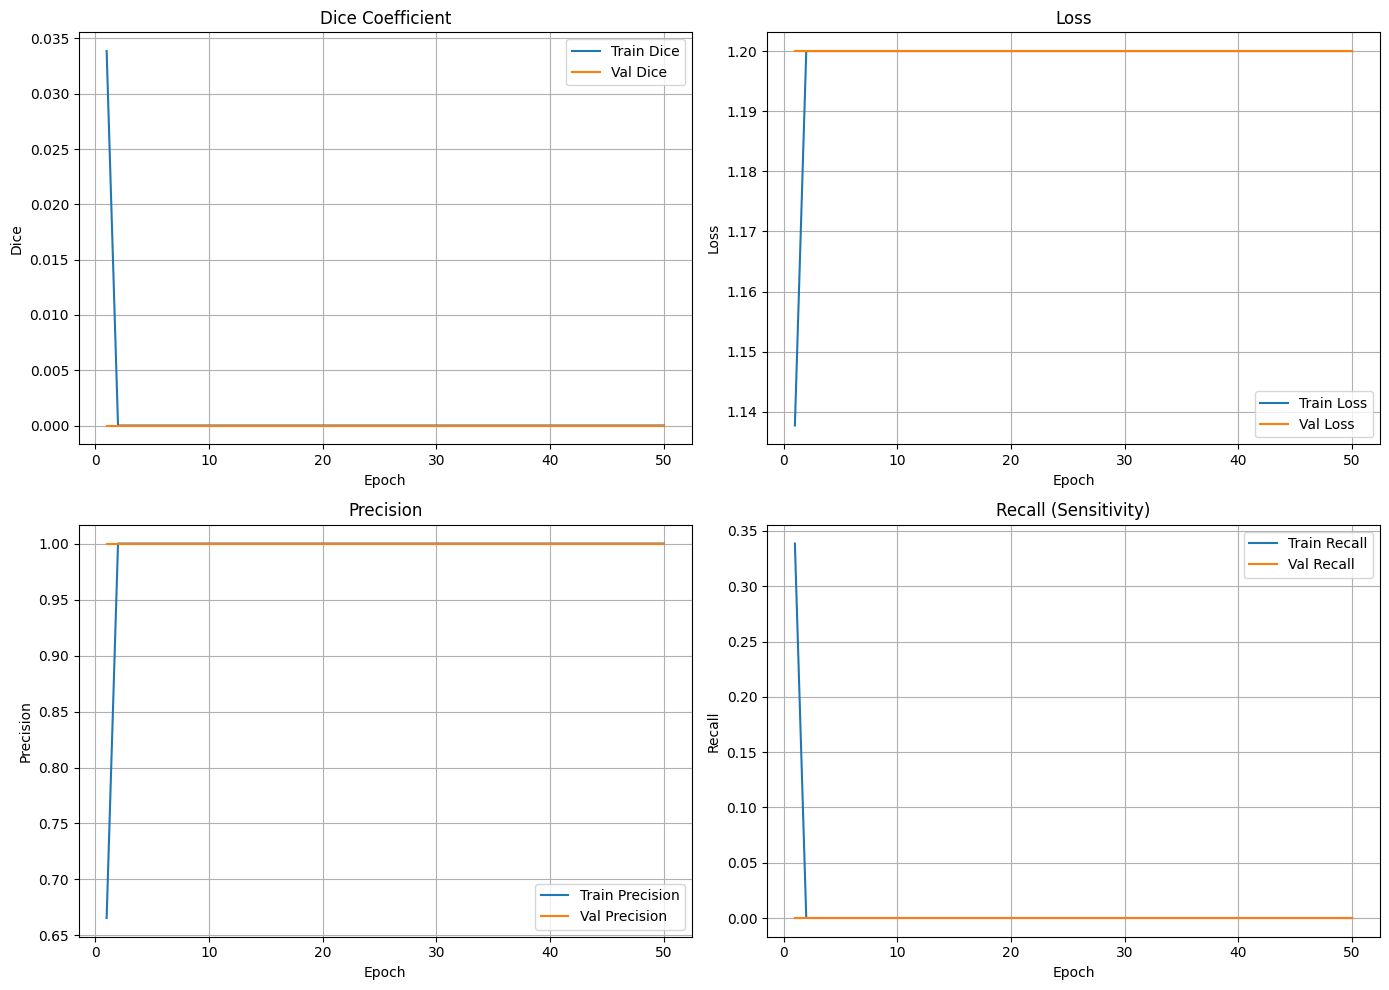

In [39]:
history = pulp_history.history
epochs = range(1, len(history['loss']) + 1)

plt.figure(figsize=(14, 10))

# 1️⃣ Dice
plt.subplot(2, 2, 1)
plt.plot(epochs, history['dice_coefficient'], label='Train Dice')
plt.plot(epochs, history['val_dice_coefficient'], label='Val Dice')
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()
plt.grid(True)

# 2️⃣ Loss
plt.subplot(2, 2, 2)
plt.plot(epochs, history['loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 3️⃣ Precision
plt.subplot(2, 2, 3)
plt.plot(epochs, history['precision_metric'], label='Train Precision')
plt.plot(epochs, history['val_precision_metric'], label='Val Precision')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# 4️⃣ Recall
plt.subplot(2, 2, 4)
plt.plot(epochs, history['recall_sensitivity'], label='Train Recall')
plt.plot(epochs, history['val_recall_sensitivity'], label='Val Recall')
plt.title('Recall (Sensitivity)')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.savefig("LossCurves_pulp.png", dpi=400)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step


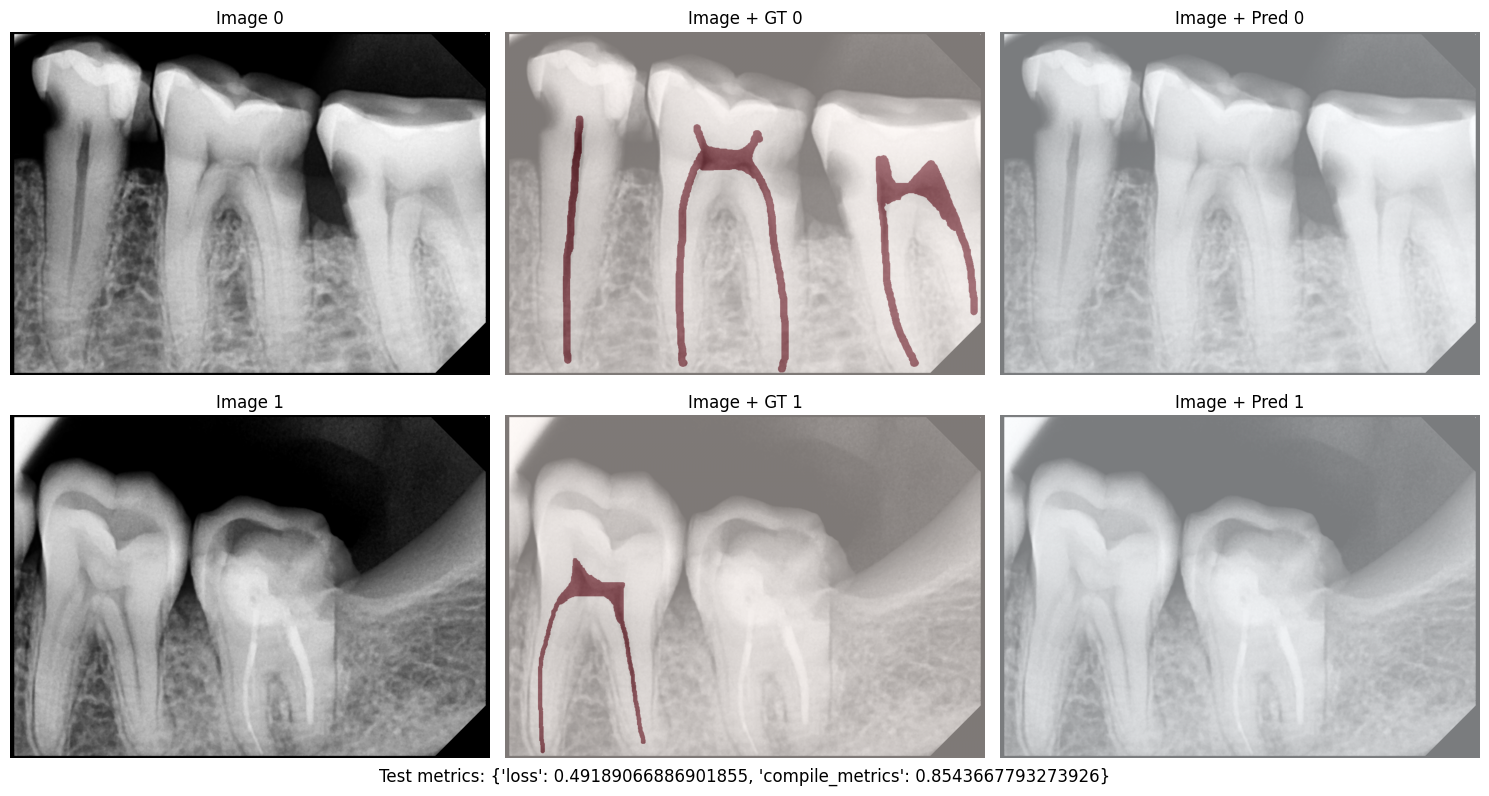

In [40]:
images, gts = next(iter(pulp_test))
pulp_preds = pulp_model.predict(images)

batch_size = images.shape[0]
threshold = 0.2   # try 0.3 later if recall is low
alpha = 0.5       # transparency for overlays

plt.figure(figsize=(15, 4 * batch_size))

for i in range(batch_size):
    img  = images[i, ..., 0]
    gt   = gts[i, ..., 0]
    pred = pulp_preds[i, ..., 0]

    # 1️⃣ Image only
    plt.subplot(batch_size, 3, i * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i}")
    plt.axis("off")

    # 2️⃣ Image + GT overlay
    plt.subplot(batch_size, 3, i * 3 + 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(gt, cmap="Reds", alpha=alpha)
    plt.title(f"Image + GT {i}")
    plt.axis("off")

    # 3️⃣ Image + Prediction overlay
    plt.subplot(batch_size, 3, i * 3 + 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(pred > threshold, cmap="Blues", alpha=alpha)
    plt.title(f"Image + Pred {i}")
    plt.axis("off")

plt.gcf().text(
    0.5, 0.02,
    f"Test metrics: {test_metrics}",
    ha="center",
    va="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("prediction_overlay_pulp.png", dpi=400,)
plt.show()


## 12. Final predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


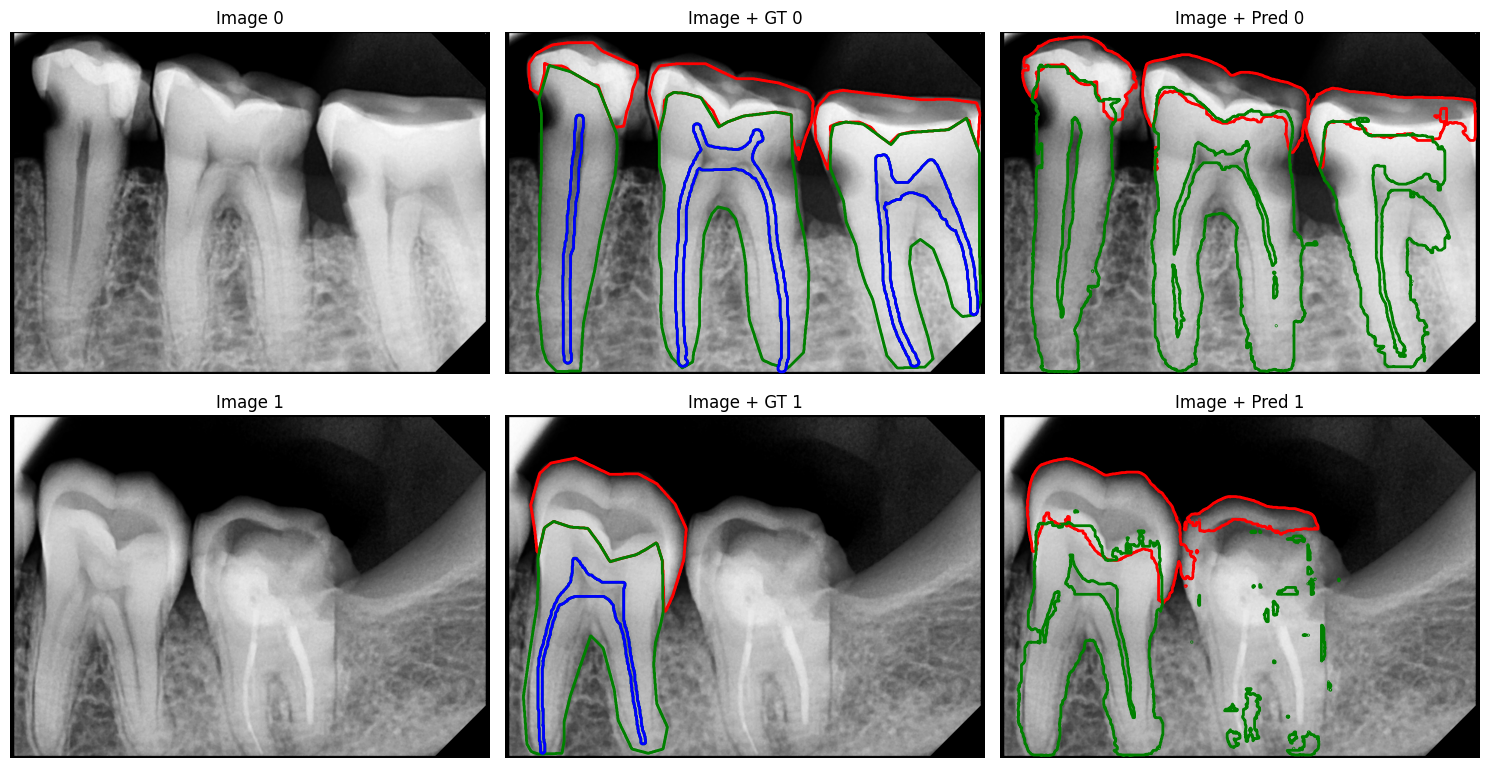

In [47]:
# Get one batch
images, gt_enamel_batch  = next(iter(enamel_test))
_,      gt_dentine_batch = next(iter(dentine_test))
_,      gt_pulp_batch    = next(iter(pulp_test))

# Predictions
pred_enamel  = enamel_model.predict(images)
pred_dentine = dentine_model.predict(images)
pred_pulp    = pulp_model.predict(images)

batch_size = images.shape[0]
threshold = 0.1
alpha = 0.5

plt.figure(figsize=(15, 4 * batch_size))

for i in range(batch_size):
    img = images[i, ..., 0]

    # ---------- GT masks ----------
    gt_enamel  = (gt_enamel_batch[i, ..., 0] == 1)
    gt_dentine = (gt_dentine_batch[i, ..., 0] == 1)
    gt_pulp    = (gt_pulp_batch[i, ..., 0] == 1)

    # ---------- Pred masks ----------
    pr_enamel  = pred_enamel[i, ..., 0]  > threshold
    pr_dentine = pred_dentine[i, ..., 0] > threshold
    pr_pulp    = pred_pulp[i, ..., 0]    > threshold

    # ---------- Image ----------
    plt.subplot(batch_size, 3, i * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i}")
    plt.axis("off")

    # ---------- Image + GT overlay ----------
    plt.subplot(batch_size, 3, i * 3 + 2)
    plt.imshow(img, cmap="gray")
    plt.contour(gt_enamel,  colors="red", linewidths=2)
    plt.contour(gt_dentine, colors="green", linewidths=2)
    plt.contour(gt_pulp,    colors="blue",  linewidths=2)
    plt.title(f"Image + GT {i}")
    plt.axis("off")

    # ---------- Image + Pred overlay ----------
    plt.subplot(batch_size, 3, i * 3 + 3)
    plt.imshow(img, cmap="gray")
    plt.contour(pr_enamel,  colors="red", linewidths=2)
    plt.contour(pr_dentine, colors="green", linewidths=2)
    plt.contour(pr_pulp,    colors="blue",  linewidths=2)
    plt.title(f"Image + Pred {i}")
    plt.axis("off")

plt.savefig("FINAL_predictions_3Unet.png", dpi=400)
plt.tight_layout()
plt.show()
